# 02 — Preprocessing sanity

Verify the scaler fits on train-only and that windowing produces expected
shapes. Real preprocessing happens inside `experiments/run.py`.


In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_hai, load_morris
from src.preprocessing import scale_bundle, make_windows
from src.utils import save_figure, set_seed

set_seed(42)
sns.set_theme(style='whitegrid', context='notebook')


In [2]:
hai = load_hai()
hai_scaled = scale_bundle(hai)
print('HAI splits:', hai_scaled.X_train.shape, hai_scaled.X_val.shape, hai_scaled.X_test.shape)

morris = load_morris()
morris_scaled = scale_bundle(morris)
print('Morris splits:', morris_scaled.X_train.shape, morris_scaled.X_val.shape, morris_scaled.X_test.shape)


HAI splits: (783363, 79) (138240, 79) (402005, 79)


Morris splits: (84274, 16) (22983, 16) (89136, 16)


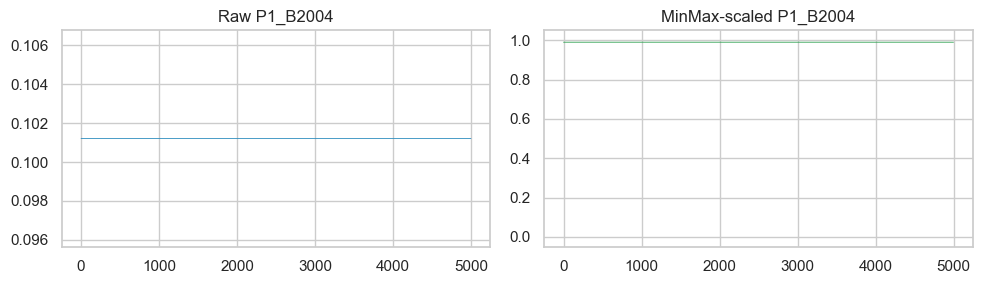

In [3]:
# Scaling effect on a single HAI sensor.
col_idx = 0
raw = hai.features.iloc[:, col_idx].to_numpy()[hai.mask('train')][:5000]
scaled = hai_scaled.X_train[:5000, col_idx]
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(raw, color='#2b8cbe', linewidth=0.6)
axes[0].set_title(f'Raw {hai_scaled.feature_names[col_idx]}')
axes[1].plot(scaled, color='#31a354', linewidth=0.6)
axes[1].set_title(f'MinMax-scaled {hai_scaled.feature_names[col_idx]}')
axes[1].set_ylim(-0.05, 1.05)
plt.tight_layout()
save_figure(fig, 'hai_scaling_effect', subdir='02_preprocessing')
plt.show()


In [4]:
windows = make_windows(hai_scaled.X_test, window=60, stride=10)
print('HAI test windows:', windows.shape)
print('Min-max of scaled training data:', hai_scaled.X_train.min(), hai_scaled.X_train.max())


HAI test windows: (40195, 60, 79)
Min-max of scaled training data: 0.0 1.0
